# BirdCLEF 2026 — Results & Model-Development Visualizations

Report figures covering (a) the **submissions delivered to Kaggle** and their public-leaderboard scores, and (b) the **autonomous agent's offline search** (per-iteration val-AUC and training curves) — the "debugging" view of how the models were developed.

Every figure is also written to `figures/*.png` for dropping straight into the report.

*Kaggle scores transcribed from the submissions page on 2026-05-20. Offline val-AUC values are read live from `experiments.jsonl`.*

In [26]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

C_EFF, C_YAM, C_BASE = '#4C72B0', '#DD8452', '#9E9E9E'
BACKBONE_COLOR = {'EfficientNet': C_EFF, 'YamNet': C_YAM, '—': C_BASE}

# ── Kaggle submissions (transcribed from the submissions page, 2026-05-20) ──────
# auc=None marks a submission whose notebook threw an exception (no score).
SUBMISSIONS = [
    {'name': 'Delivery 1 (baseline)',          'backbone': '—',            'approach': 'Baseline',              'version': 2, 'auc': 0.512},
    {'name': 'First — EfficientNet',            'backbone': 'EfficientNet', 'approach': 'First',                 'version': 7, 'auc': 0.632},
    {'name': 'Soundscape Val — EfficientNet',   'backbone': 'EfficientNet', 'approach': 'Soundscape Validation', 'version': 3, 'auc': 0.711},
    {'name': 'Data Augmentation — EfficientNet','backbone': 'EfficientNet', 'approach': 'Data Augmentation',     'version': 2, 'auc': 0.715},
    {'name': 'Data Augmentation — YamNet',      'backbone': 'YamNet',       'approach': 'Data Augmentation',     'version': 4, 'auc': 0.733},
    {'name': 'First — YamNet',                  'backbone': 'YamNet',       'approach': 'First',                 'version': 3, 'auc': 0.745},
    {'name': 'Delivery 3',                      'backbone': '—',            'approach': 'Delivery',              'version': 3, 'auc': None},
]

# ── Agent offline experiment log ───────────────────────────────────────────────
with open('experiments.jsonl') as f:
    EXP = [json.loads(l) for l in f if l.strip()]
EXP = [e for e in EXP if e.get('val_auc') is not None]

done   = [s for s in SUBMISSIONS if s['auc'] is not None]
failed = [s for s in SUBMISSIONS if s['auc'] is None]
print(f'Scored submissions: {len(done)} | failed: {len(failed)} | offline experiments: {len(EXP)}')
print(f'Best public LB: {max(s["auc"] for s in done):.3f} | best offline val_auc: {max(e["val_auc"] for e in EXP):.4f}')

Scored submissions: 6 | failed: 1 | offline experiments: 25
Best public LB: 0.745 | best offline val_auc: 0.9318


## 1. Kaggle public-leaderboard scoreboard

Every scored submission, ranked by public macro ROC-AUC and coloured by backbone. The dashed line is random (0.5). The progression tells the story: a broken zero-filled baseline (0.512) → first EfficientNet head (0.632) → soundscape-validation regime (0.711) → augmentation (0.715), with the **YamNet backbone** taking the top spot (0.745).

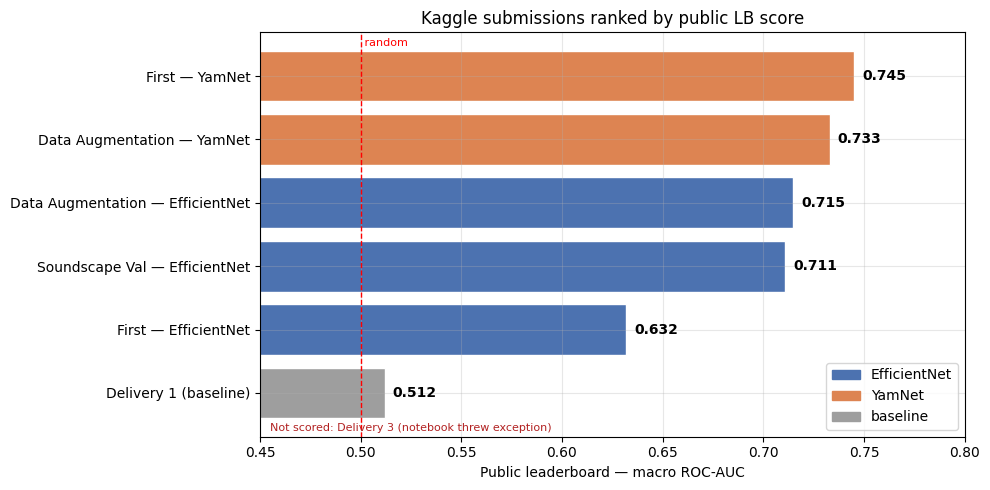

In [27]:
ds = sorted(done, key=lambda s: s['auc'])
vals   = [s['auc'] for s in ds]
bar_c  = [BACKBONE_COLOR[s['backbone']] for s in ds]
y = np.arange(len(ds))

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(y, vals, color=bar_c, edgecolor='white')
for i, s in enumerate(ds):
    ax.text(s['auc'] + 0.004, i, f"{s['auc']:.3f}", va='center', fontweight='bold')
ax.axvline(0.5, color='red', ls='--', lw=1)
ax.text(0.5, len(ds) - 0.4, ' random', color='red', fontsize=8, va='top')
ax.set_yticks(y); ax.set_yticklabels([s['name'] for s in ds])
ax.set_xlim(0.45, 0.80)
ax.set_xlabel('Public leaderboard — macro ROC-AUC')
ax.set_title('Kaggle submissions ranked by public LB score')
ax.legend(handles=[Patch(color=C_EFF, label='EfficientNet'),
                   Patch(color=C_YAM, label='YamNet'),
                   Patch(color=C_BASE, label='baseline')],
          loc='lower right')
if failed:
    ax.text(0.455, -0.6, 'Not scored: ' + ', '.join(f['name'] for f in failed) + ' (notebook threw exception)',
            fontsize=8, color='firebrick')
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/kaggle_scoreboard.png', dpi=150, bbox_inches='tight'); plt.show()

## 2. Backbone comparison — EfficientNet vs YamNet

Grouped by approach. **YamNet** (trained on AudioSet, i.e. closer to the bioacoustic domain) beats EfficientNet (ImageNet) on the matched *First* configuration by a wide margin (0.745 vs 0.632) and stays ahead under augmentation — the single biggest lever we found.

*The **YamNet × Soundscape-Validation** combination is marked **✗ errored**, not blank: that configuration consistently threw exceptions and never produced a working submission, so it has no score (it was attempted, not skipped).*

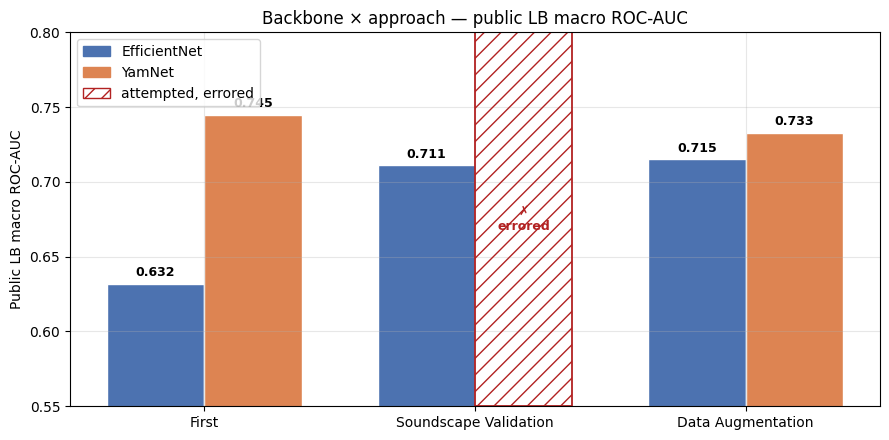

In [28]:
approaches = ['First', 'Soundscape Validation', 'Data Augmentation']
backbones  = ['EfficientNet', 'YamNet']

# Combos attempted but that consistently ERRORED (never produced a working submission),
# as opposed to combos we simply never submitted. Marked distinctly below.
FAILED = {('Soundscape Validation', 'YamNet')}

def lookup(approach, backbone):
    for s in done:
        if s['approach'] == approach and s['backbone'] == backbone:
            return s['auc']
    return np.nan

FLOOR, TOP = 0.55, 0.80
x = np.arange(len(approaches)); w = 0.36
fig, ax = plt.subplots(figsize=(9, 4.5))
for j, bb in enumerate(backbones):
    xpos = x + (j - 0.5) * w
    scores = [lookup(a, bb) for a in approaches]
    ax.bar(xpos, scores, w, label=bb, color=BACKBONE_COLOR[bb], edgecolor='white')
    for a, xi, v in zip(approaches, xpos, scores):
        if not np.isnan(v):
            ax.text(xi, v + 0.005, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
        elif (a, bb) in FAILED:
            # mark the slot as a failed run WITHOUT implying any score value
            ax.bar(xi, TOP - FLOOR, w, bottom=FLOOR, color='none',
                   edgecolor='firebrick', hatch='//', lw=1.3, zorder=2)
            ax.text(xi, (FLOOR + TOP) / 2, '✗\nerrored', ha='center', va='center',
                    color='firebrick', fontsize=9, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(approaches)
ax.set_ylim(FLOOR, TOP); ax.set_ylabel('Public LB macro ROC-AUC')
ax.set_title('Backbone × approach — public LB macro ROC-AUC')
ax.legend(handles=[Patch(color=C_EFF, label='EfficientNet'),
                   Patch(color=C_YAM, label='YamNet'),
                   Patch(facecolor='none', edgecolor='firebrick', hatch='//', label='attempted, errored')],
          loc='upper left')
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/backbone_comparison.png', dpi=150, bbox_inches='tight'); plt.show()

## 3. Offline validation vs public leaderboard — the domain-shift gap

The agent optimised an **offline** val-AUC (~0.90+), but the **online** leaderboard scores it far lower. That gap *is* the domain shift (clean focal clips → noisy Pantanal soundscapes). Note how the **soundscape-validation regime narrows the gap** versus plain clip-validation — exactly why it lifted the LB.

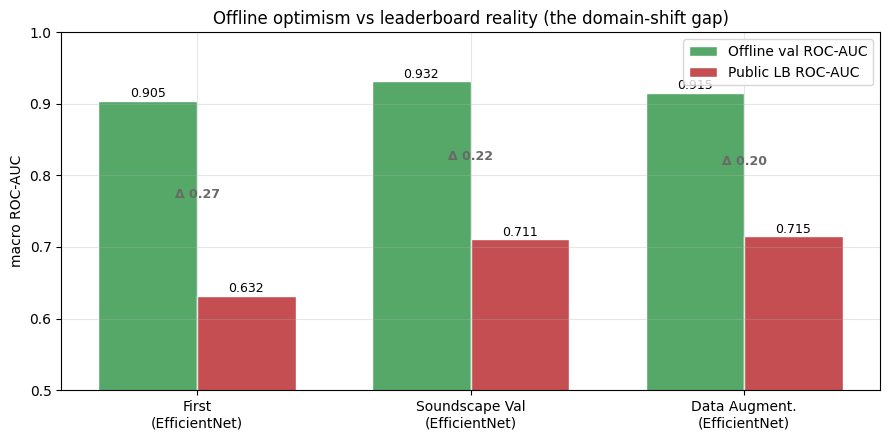

In [29]:
# Offline = best val_auc of the run behind each EfficientNet approach; online = its public LB.
pairs = [
    ('First\n(EfficientNet)',          0.9047, 0.632),
    ('Soundscape Val\n(EfficientNet)', 0.9318, 0.711),
    ('Data Augment.\n(EfficientNet)',  0.9153, 0.715),
]
labels   = [p[0] for p in pairs]
offline  = [p[1] for p in pairs]
online   = [p[2] for p in pairs]
x = np.arange(len(pairs)); w = 0.36

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x - w/2, offline, w, label='Offline val ROC-AUC', color='#55A868', edgecolor='white')
ax.bar(x + w/2, online,  w, label='Public LB ROC-AUC',   color='#C44E52', edgecolor='white')
for xi, o, n in zip(x, offline, online):
    ax.text(xi - w/2, o + 0.005, f'{o:.3f}', ha='center', fontsize=9)
    ax.text(xi + w/2, n + 0.005, f'{n:.3f}', ha='center', fontsize=9)
    ax.annotate(f'Δ {o-n:.2f}', (xi, (o+n)/2), ha='center', fontsize=9, color='dimgray', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0.5, 1.0); ax.set_ylabel('macro ROC-AUC')
ax.set_title('Offline optimism vs leaderboard reality (the domain-shift gap)')
ax.legend(loc='upper right')
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/offline_vs_leaderboard.png', dpi=150, bbox_inches='tight'); plt.show()

## 4. Autonomous agent search — per-iteration progression

The "debugging" view: every architecture the LLM proposed across the nightly runs, plotted by offline val-AUC in chronological order and coloured by run. Each point is one LLM-designed head that was trained and evaluated; the search is noisy (some heads collapse) but the best designs cluster near the top.

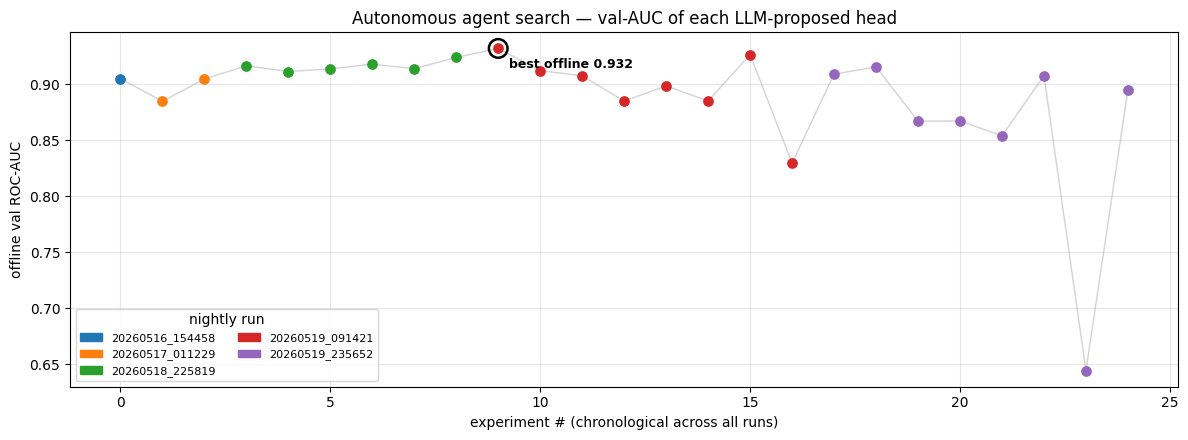

In [30]:
runs = sorted({e['run_id'] for e in EXP})
cmap = plt.cm.tab10
run_color = {rid: cmap(i % 10) for i, rid in enumerate(runs)}

xs = np.arange(len(EXP))
ys = [e['val_auc'] for e in EXP]

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(xs, ys, color='lightgray', lw=1, zorder=0)
for i, e in enumerate(EXP):
    ax.scatter(i, e['val_auc'], color=run_color[e['run_id']], s=45, zorder=3)
bi = int(np.argmax(ys))
ax.scatter(bi, ys[bi], s=180, facecolors='none', edgecolors='black', lw=1.8, zorder=4)
ax.annotate(f"best offline {ys[bi]:.3f}", (bi, ys[bi]), textcoords='offset points',
            xytext=(8, -14), fontsize=9, fontweight='bold')
ax.set_xlabel('experiment # (chronological across all runs)')
ax.set_ylabel('offline val ROC-AUC')
ax.set_title('Autonomous agent search — val-AUC of each LLM-proposed head')
ax.legend(handles=[Patch(color=run_color[r], label=r.replace('run_', '')) for r in runs],
          title='nightly run', fontsize=8, ncol=2, loc='lower left')
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/agent_search_progression.png', dpi=150, bbox_inches='tight'); plt.show()

## 5. Training curves — validation loss / ROC-AUC across iterations

For the **Kaggle-best run of each backbone**, every LLM-proposed iteration's *validation* loss and ROC-AUC over its training epochs (legend = each iteration's best val-AUC). This shows how the agent's heads converge and how much they vary within a single run.

- **EfficientNet** — augmentation run (public LB **0.715**), regenerated from the experiment log.
- **YamNet** — First run (public LB **0.745**, best overall). Its per-epoch numbers are no longer in the YamNet log (the file was reset), so this is the original chart saved at run time.

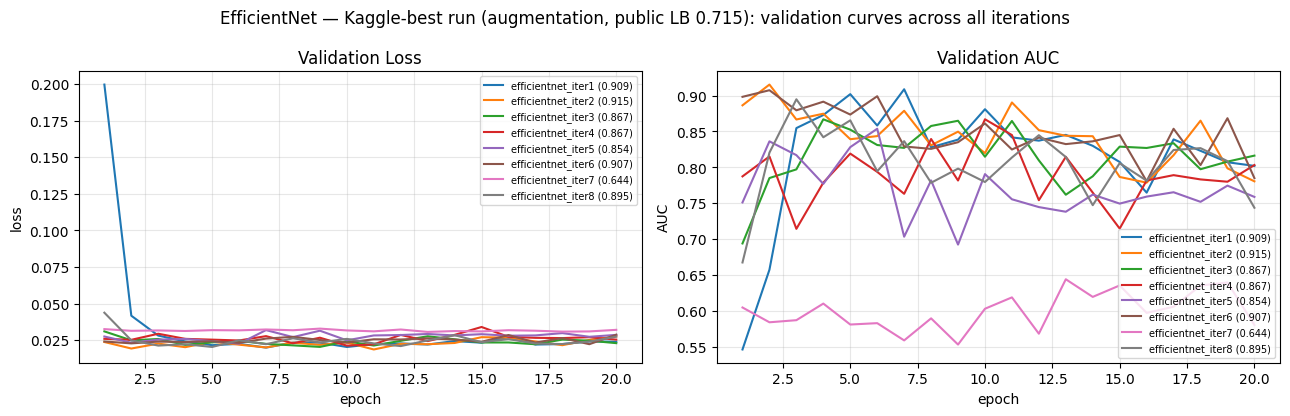

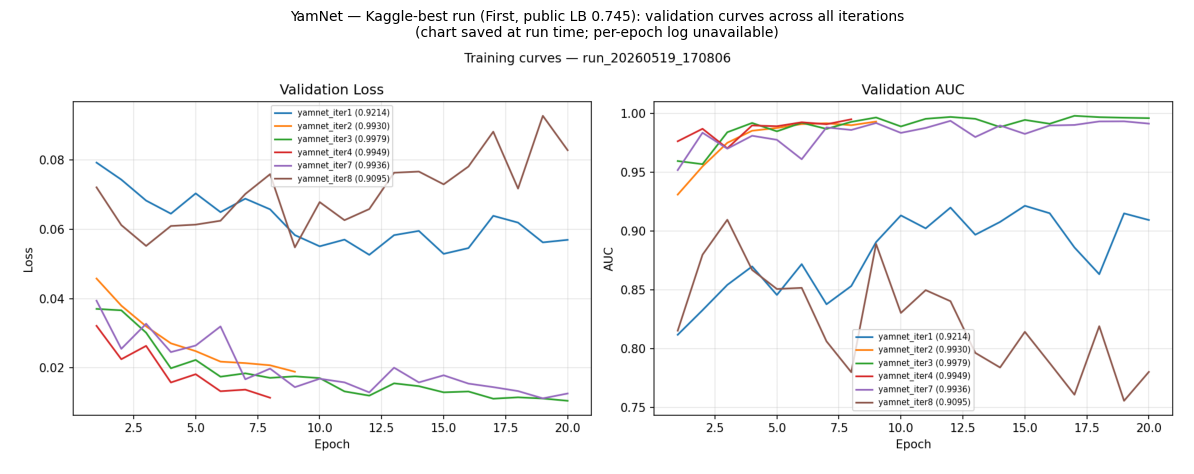

In [31]:
import shutil
import matplotlib.image as mpimg

# ── 5a. EfficientNet — Kaggle-best run (augmentation, public LB 0.715) ─────────
# Same view as the YamNet chart: VALIDATION loss + ROC-AUC for EVERY LLM-proposed
# iteration of the best run, regenerated from the experiment log. (run_id ↔
# runs/augmentation_efficientnet/; legend shows each iteration's best val-AUC.)
EFF_BEST_RUN = 'run_20260519_235652'
eff_iters = sorted([e for e in EXP if e['run_id'] == EFF_BEST_RUN and e.get('epoch_history')],
                   key=lambda e: e.get('iteration', 0))
cmap = plt.cm.tab10

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
for k, e in enumerate(eff_iters):
    h = e['epoch_history']
    ep = np.arange(1, len(h['val_loss']) + 1)
    color = cmap(k % 10)
    label = f"{e['label']} ({e['val_auc']:.3f})"
    ax[0].plot(ep, h['val_loss'], color=color, label=label)
    ax[1].plot(ep, h['val_auc'],  color=color, label=label)
ax[0].set_title('Validation Loss'); ax[0].set_xlabel('epoch'); ax[0].set_ylabel('loss')
ax[1].set_title('Validation AUC');  ax[1].set_xlabel('epoch'); ax[1].set_ylabel('AUC')
ax[0].legend(fontsize=7, loc='upper right'); ax[1].legend(fontsize=7, loc='lower right')
fig.suptitle('EfficientNet — Kaggle-best run (augmentation, public LB 0.715): '
             'validation curves across all iterations')
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/efficientnet_best_training_curves.png', dpi=150, bbox_inches='tight'); plt.show()

# ── 5b. YamNet — Kaggle-best run (First, public LB 0.745) ──────────────────────
# Same view, but this run's per-epoch numbers are no longer in the YamNet log
# (it was reset), so we embed the chart saved at run time (run_20260519_170806).
YAMNET_CURVES = 'Yamnet runs/runs/First_yamnet/training_curves.png'
if os.path.exists(YAMNET_CURVES):
    shutil.copyfile(YAMNET_CURVES, f'{FIG_DIR}/yamnet_best_training_curves.png')   # full-res copy for the report
    img = mpimg.imread(YAMNET_CURVES)
    fig, ax = plt.subplots(figsize=(13, 4.8))
    ax.imshow(img); ax.axis('off')
    ax.set_title('YamNet — Kaggle-best run (First, public LB 0.745): '
                 'validation curves across all iterations\n'
                 '(chart saved at run time; per-epoch log unavailable)', fontsize=10)
    plt.tight_layout(); plt.show()
else:
    print('YamNet saved curve not found:', YAMNET_CURVES)

## 6. Crashes & agent self-correction

LLM-generated code doesn't always run first time. Each proposed head goes through an **execute-and-repair loop**: when the code throws, the traceback is fed back to the LLM, which patches it — `crash_count` records how many repair attempts an iteration needed before it trained. The left panel breaks crashes down per nightly run (clean vs crashed-then-recovered iterations); the right panel shows how many iterations needed 0, 1, or 2 repairs.

**Every crash was recovered** — no iteration was lost and no run aborted. This self-correction is what lets the agent run unattended overnight. (This is the agent's *local* code-crash log; it is separate from the single Kaggle submission that threw an exception, shown in §1–§2.)

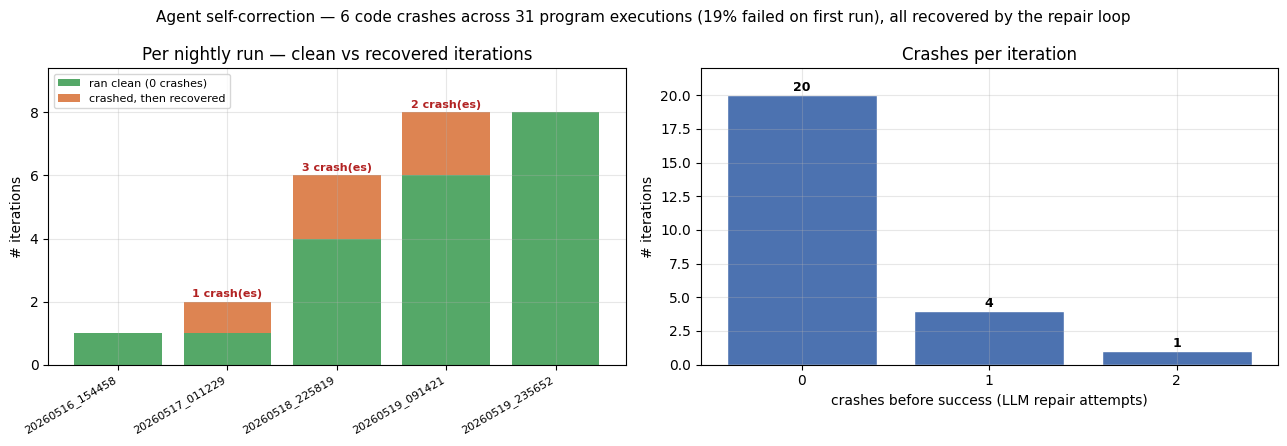

Crashes: 6 | clean iterations: 20 | recovered iterations: 5 | aborted: 0


In [32]:
from collections import defaultdict, Counter

# crash_count = how many times an LLM-proposed program threw an exception and was
# auto-patched by the execute-and-repair loop before it finally trained. Every logged
# experiment is a SUCCESS, so each crash here was recovered (none aborted the run).
crashes_by_run      = defaultdict(int)
exps_by_run         = defaultdict(int)
crashed_exps_by_run = defaultdict(int)
for e in EXP:
    rid = e['run_id']; c = e.get('crash_count', 0) or 0
    crashes_by_run[rid] += c
    exps_by_run[rid]    += 1
    if c > 0:
        crashed_exps_by_run[rid] += 1

runs  = sorted(exps_by_run)
short = [r.replace('run_', '') for r in runs]
total_crashes  = sum(crashes_by_run.values())
total_attempts = len(EXP) + total_crashes      # each crash = one extra program execution
crash_rate     = 100 * total_crashes / total_attempts

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel A — per nightly run: iterations that ran clean vs crashed-then-recovered
clean = [exps_by_run[r] - crashed_exps_by_run[r] for r in runs]
recov = [crashed_exps_by_run[r]                  for r in runs]
xr = np.arange(len(runs))
ax[0].bar(xr, clean, color='#55A868', label='ran clean (0 crashes)')
ax[0].bar(xr, recov, bottom=clean, color='#DD8452', label='crashed, then recovered')
for i, r in enumerate(runs):
    if crashes_by_run[r]:
        ax[0].text(i, exps_by_run[r] + 0.15, f'{crashes_by_run[r]} crash(es)',
                   ha='center', fontsize=8, color='firebrick', fontweight='bold')
ax[0].set_ylim(0, max(exps_by_run.values()) + 1.4)   # headroom for the crash-count labels
ax[0].set_xticks(xr); ax[0].set_xticklabels(short, rotation=30, ha='right', fontsize=8)
ax[0].set_ylabel('# iterations'); ax[0].set_title('Per nightly run — clean vs recovered iterations')
ax[0].legend(fontsize=8, loc='upper left')

# Panel B — how many repair attempts each iteration needed before success
dist = Counter(e.get('crash_count', 0) or 0 for e in EXP)
ks   = sorted(dist)
ax[1].bar([str(k) for k in ks], [dist[k] for k in ks], color='#4C72B0', edgecolor='white')
for k in ks:
    ax[1].text(str(k), dist[k] + 0.3, str(dist[k]), ha='center', fontsize=9, fontweight='bold')
ax[1].set_ylim(0, max(dist.values()) + 2)
ax[1].set_xlabel('crashes before success (LLM repair attempts)')
ax[1].set_ylabel('# iterations'); ax[1].set_title('Crashes per iteration')

fig.suptitle(f'Agent self-correction — {total_crashes} code crashes across {total_attempts} program '
             f'executions ({crash_rate:.0f}% failed on first run), all recovered by the repair loop',
             fontsize=11)
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/crash_analysis.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'Crashes: {total_crashes} | clean iterations: {sum(clean)} | recovered iterations: {sum(recov)} | aborted: 0')

## Takeaways

- **Best submission: YamNet, public LB 0.745** — the bioacoustic-pretrained backbone beats ImageNet EfficientNet (0.632 on the matched *First* config).
- **Steady climb on EfficientNet:** broken baseline 0.512 → 0.632 → soundscape-val 0.711 → augmentation 0.715.
- **Large offline→online gap (~0.20–0.27):** offline val-AUC is optimistic; the soundscape-validation regime measurably narrows it, confirming it as the more honest validation signal.
- **The agent search is exploratory and noisy:** many LLM-proposed heads underperform, but the autonomous loop reliably surfaces strong designs near the top of each run.
- **Robust self-correction:** 6 code crashes across the nightly runs, all auto-recovered by the execute-and-repair loop — no iteration lost (see §6).